In [ ]:
# ============================================
# FEATURE ENGINEERING POUR TFT
# ============================================
# Objectif: Préparer les données pour le Temporal Fusion Transformer
# Input: financial_data_with_sentiment.csv (35,200 lignes, 20 tickers)
# Output: train/val/test splits + features TFT

# Setup du projet
import sys
from pathlib import Path

project_root = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(project_root))

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

from src.utils.config import get_config
from src.utils.logger import get_logger

# Configuration
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

logger = get_logger(__name__)

print("✅ Imports réussis")
print(f"📁 Project root: {project_root}")


✅ Imports réussis
📁 Project root: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2


In [2]:
# ============================================
# CHARGEMENT DES DONNÉES AVEC SENTIMENT
# ============================================

config = get_config()

print("=" * 70)
print("📂 CHARGEMENT DES DONNÉES AVEC SENTIMENT")
print("=" * 70)

# Charger le fichier avec sentiment (généré par notebook 03)
data_path = config.data_dir / 'processed' / 'financial_data_with_sentiment.csv'

if not data_path.exists():
    raise FileNotFoundError(
        f"❌ Fichier non trouvé: {data_path}\n"
        f"⚠️  Exécute d'abord 03_sentiment_analysis.ipynb"
    )

df = pd.read_csv(data_path)
df['Date'] = pd.to_datetime(df['Date'])

print(f"\n✅ Données chargées avec succès")
print(f"   Lignes: {len(df):,}")
print(f"   Période: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"   Tickers: {df['Ticker'].nunique()}")
print(f"   Durée: {(df['Date'].max() - df['Date'].min()).days / 365.25:.1f} ans")

print(f"\n📊 Colonnes disponibles ({len(df.columns)}):")
for col in df.columns:
    print(f"   - {col}")

print("\n🔍 Vérification des valeurs manquantes:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ Aucune valeur manquante")
else:
    print(missing[missing > 0])

print("=" * 70)

# Aperçu
display(df.head(10))
display(df.describe())


📂 CHARGEMENT DES DONNÉES AVEC SENTIMENT

✅ Données chargées avec succès
   Lignes: 35,200
   Période: 2018-01-02 → 2024-12-30
   Tickers: 20
   Durée: 7.0 ans

📊 Colonnes disponibles (18):
   - Date
   - Close
   - High
   - Low
   - Open
   - Volume
   - Ticker
   - HMA
   - RSI
   - MACD
   - MACD_Signal
   - MACD_Hist
   - Returns
   - Volatility
   - momentum_5d
   - sentiment_score
   - sentiment_confidence
   - sentiment_label

🔍 Vérification des valeurs manquantes:
HMA                     440
RSI                     260
Returns                  20
Volatility               40
momentum_5d              20
sentiment_confidence     20
dtype: int64


,Date,Close,High,Low,Open,Volume,Ticker,HMA,RSI,MACD,MACD_Signal,MACD_Hist,Returns,Volatility,momentum_5d,sentiment_score,sentiment_confidence,sentiment_label
0,2018-01-02,40.341888,40.351258,39.639313,39.850088,102223600,AAPL,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.0,NaN,neutral
1,2018-01-03,40.334858,40.878185,40.271629,40.405116,118071600,AAPL,NaN,NaN,-0.000561,-0.000112,-0.000449,-0.000174,NaN,-0.000174,0.0,0.5,neutral
2,2018-01-04,40.522221,40.625266,40.299739,40.407465,89738400,AAPL,NaN,NaN,0.013952,0.002701,0.011252,0.004645,0.003408,0.002235,1.0,0.5,positive
3,2018-01-05,40.983582,41.070231,40.526908,40.618243,94640000,AAPL,NaN,NaN,0.061968,0.014554,0.047414,0.011385,0.005806,0.005285,1.0,0.5,positive
4,2018-01-08,40.831348,41.126429,40.732985,40.831348,82271200,AAPL,NaN,NaN,0.086737,0.028991,0.057746,-0.003714,0.006536,0.003035,0.0,0.5,neutral
5,2018-01-09,40.826668,40.997627,40.611212,40.878190,86336000,AAPL,NaN,NaN,0.104781,0.044149,0.060632,-0.000115,0.005833,0.002405,0.0,0.5,neutral
6,2018-01-10,40.817284,40.819628,40.515178,40.552649,95839600,AAPL,NaN,NaN,0.116975,0.058714,0.058261,-0.000230,0.005327,0.002394,1.0,0.5,positive
7,2018-01-11,41.049145,41.098327,40.864135,40.887552,74670800,AAPL,NaN,NaN,0.143692,0.075710,0.067982,0.005680,0.005062,0.002601,1.0,0.5,positive
8,2018-01-12,41.473042,41.536274,41.135805,41.259926,101672400,AAPL,NaN,NaN,0.196802,0.099928,0.096874,0.010327,0.005443,0.002390,0.0,0.5,neutral
9,2018-01-16,41.262264,42.011677,41.250554,41.662730,118263600,AAPL,NaN,NaN,0.219355,0.123814,0.095542,-0.005082,0.005836,0.002116,1.0,0.5,positive


,Date,Close,High,Low,Open,Volume,HMA,RSI,MACD,MACD_Signal,MACD_Hist,Returns,Volatility,momentum_5d,sentiment_score,sentiment_confidence
count,35200,35200.000000,35200.000000,35200.000000,35200.000000,3.520000e+04,34760.000000,34940.000000,35200.000000,35200.000000,35200.000000,35180.000000,35160.000000,35180.000000,35200.000000,35180.000000
mean,2021-06-30 22:10:21.818181888,131.310808,132.815432,129.754643,131.298045,5.485254e+07,131.814645,53.172436,0.554791,0.550605,0.004186,0.000811,0.018437,0.000826,0.000000,0.501214
min,2018-01-02 00:00:00,3.150568,3.222465,3.085612,3.135941,5.857000e+05,3.099239,1.275109,-56.994680,-47.845443,-16.104680,-0.263901,0.001374,-0.108817,-1.000000,0.500000
25%,2019-10-01 18:00:00,39.988022,40.391814,39.583437,40.001507,8.728750e+06,40.133639,40.944402,-0.511607,-0.462300,-0.270779,-0.008611,0.011346,-0.003685,-1.000000,0.500000
50%,2021-06-30 12:00:00,109.214008,110.531787,107.896775,109.312734,2.079600e+07,109.946816,53.417936,0.233777,0.233079,0.011128,0.000791,0.015644,0.000900,0.000000,0.500000
75%,2023-03-30 06:00:00,184.558273,186.727911,182.115989,184.494092,4.704765e+07,184.631107,65.653562,1.555707,1.487180,0.307792,0.010098,0.021674,0.005268,1.000000,0.500000
max,2024-12-30 00:00:00,630.182861,635.880317,624.734467,629.007513,2.511528e+09,640.801756,98.836479,40.538606,34.756622,10.296174,0.243696,0.139917,0.134711,1.000000,0.869950
std,NaN,111.552762,112.797668,110.265456,111.550851,1.127452e+08,111.933883,16.963115,3.810769,3.551044,1.172642,0.021604,0.011303,0.009423,0.812206,0.011670


In [3]:
# ============================================
# NETTOYAGE PRÉLIMINAIRE
# ============================================

print("\n" + "=" * 70)
print(" NETTOYAGE PRÉLIMINAIRE")
print("=" * 70)

# Trier par ticker et date
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# Remplir les valeurs manquantes par groupe de ticker
print("\n📊 Traitement des NaN...")

# 1. Returns: remplir avec 0 pour le premier jour
df['Returns'] = df.groupby('Ticker')['Returns'].fillna(0)

# 2. HMA: forward fill
if 'HMA' in df.columns:
    df['HMA'] = df.groupby('Ticker')['HMA'].fillna(method='ffill')
    df['HMA'] = df['HMA'].fillna(df['Close'])  # Si encore NaN, utiliser Close

# 3. RSI: remplir avec 50 (neutre)
if 'RSI' in df.columns:
    df['RSI'] = df['RSI'].fillna(50)

# 4. MACD: remplir avec 0
macd_cols = ['MACD', 'MACD_Signal', 'MACD_Hist']
for col in macd_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 5. Sentiment: déjà complet normalement
if 'sentiment_confidence' in df.columns:
    df['sentiment_confidence'] = df['sentiment_confidence'].fillna(0.5)

# 6. Volume: forward fill
df['Volume'] = df.groupby('Ticker')['Volume'].fillna(method='ffill')

# Vérification finale
missing_after = df.isnull().sum().sum()
print(f"\n✅ Nettoyage terminé")
print(f"   NaN restants: {missing_after}")

if missing_after > 0:
    print("\n⚠️  Valeurs manquantes restantes:")
    print(df.isnull().sum()[df.isnull().sum() > 0])
else:
    print("   ✅ Dataset propre !")

print("=" * 70)



 NETTOYAGE PRÉLIMINAIRE

📊 Traitement des NaN...

✅ Nettoyage terminé
   NaN restants: 60

⚠️  Valeurs manquantes restantes:
Volatility     40
momentum_5d    20
dtype: int64


In [4]:
# ============================================
# CRÉATION DES FEATURES TEMPORELLES
# ============================================

print("\n" + "=" * 70)
print("📅 CRÉATION DES FEATURES TEMPORELLES")
print("=" * 70)

# Features temporelles basiques
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day
df['day_of_week'] = df['Date'].dt.dayofweek  # 0=Lundi, 6=Dimanche
df['day_of_year'] = df['Date'].dt.dayofyear
df['quarter'] = df['Date'].dt.quarter

# Features cycliques (captures la périodicité)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Time index (pour TFT - CRUCIAL)
df['time_idx'] = df.groupby('Ticker').cumcount()

# Group ID (pour TFT)
df['group_id'] = df['Ticker'].astype('category').cat.codes

print(f"\n✅ Features temporelles créées")
print(f"   - Basiques: year, month, day, day_of_week, day_of_year, quarter")
print(f"   - Cycliques: month_sin/cos, day_of_week_sin/cos")
print(f"   - TFT: time_idx, group_id")

# Vérifier time_idx
print(f"\n📊 Vérification time_idx:")
time_idx_stats = df.groupby('Ticker')['time_idx'].agg(['min', 'max', 'count'])
print(time_idx_stats.head())

print("=" * 70)
display(df[['Date', 'Ticker', 'time_idx', 'month', 'day_of_week', 'month_sin', 'day_of_week_sin']].head(10))



📅 CRÉATION DES FEATURES TEMPORELLES

✅ Features temporelles créées
   - Basiques: year, month, day, day_of_week, day_of_year, quarter
   - Cycliques: month_sin/cos, day_of_week_sin/cos
   - TFT: time_idx, group_id

📊 Vérification time_idx:
        min   max  count
Ticker                  
AAPL      0  1759   1760
AMZN      0  1759   1760
BA        0  1759   1760
BAC       0  1759   1760
CAT       0  1759   1760


,Date,Ticker,time_idx,month,day_of_week,month_sin,day_of_week_sin
0,2018-01-02,AAPL,0,1,1,0.5,0.781831
1,2018-01-03,AAPL,1,1,2,0.5,0.974928
2,2018-01-04,AAPL,2,1,3,0.5,0.433884
3,2018-01-05,AAPL,3,1,4,0.5,-0.433884
4,2018-01-08,AAPL,4,1,0,0.5,0.000000
5,2018-01-09,AAPL,5,1,1,0.5,0.781831
6,2018-01-10,AAPL,6,1,2,0.5,0.974928
7,2018-01-11,AAPL,7,1,3,0.5,0.433884
8,2018-01-12,AAPL,8,1,4,0.5,-0.433884
9,2018-01-16,AAPL,9,1,1,0.5,0.781831


In [5]:
# ============================================
# CRÉATION DES LAG FEATURES
# ============================================

print("\n" + "=" * 70)
print("⏮️  CRÉATION DES LAG FEATURES")
print("=" * 70)

def create_lag_features(df, columns, lags=[1, 2, 3, 5, 10]):
    """
    Créer des features lag pour capturer l'historique récent
    """
    df_lags = df.copy()
    
    for col in columns:
        for lag in lags:
            df_lags[f'{col}_lag_{lag}'] = df_lags.groupby('Ticker')[col].shift(lag)
    
    return df_lags

# Colonnes pour les lags
lag_columns = [
    'Close',
    'Volume',
    'Returns',
    'RSI',
    'MACD',
    'MACD_Hist',
    'sentiment_score',
    'sentiment_confidence'
]

print(f"\n📊 Création des lags pour {len(lag_columns)} colonnes...")
print(f"   Lags: [1, 2, 3, 5, 10]")

df = create_lag_features(df, lag_columns, lags=[1, 2, 3, 5, 10])

lag_cols_created = [col for col in df.columns if '_lag_' in col]
print(f"\n✅ {len(lag_cols_created)} features lag créées")
print(f"   Exemples: {lag_cols_created[:5]}")

print("=" * 70)



⏮️  CRÉATION DES LAG FEATURES

📊 Création des lags pour 8 colonnes...
   Lags: [1, 2, 3, 5, 10]

✅ 40 features lag créées
   Exemples: ['Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_5', 'Close_lag_10']


In [6]:
# ============================================
# CRÉATION DES ROLLING FEATURES
# ============================================

print("\n" + "=" * 70)
print("📈 CRÉATION DES ROLLING FEATURES")
print("=" * 70)

def create_rolling_features(df, columns, windows=[5, 10, 20]):
    """
    Créer des statistiques rolling pour capturer tendances et volatilité
    """
    df_rolling = df.copy()
    
    for col in columns:
        for window in windows:
            # Rolling mean
            df_rolling[f'{col}_ma_{window}'] = (
                df_rolling.groupby('Ticker')[col]
                .rolling(window=window, min_periods=1)
                .mean()
                .reset_index(0, drop=True)
            )
            
            # Rolling std (volatilité)
            df_rolling[f'{col}_std_{window}'] = (
                df_rolling.groupby('Ticker')[col]
                .rolling(window=window, min_periods=1)
                .std()
                .reset_index(0, drop=True)
            )
    
    return df_rolling

# Colonnes pour rolling
rolling_columns = [
    'Close',
    'Returns',
    'Volume',
    'RSI',
    'sentiment_score'
]

print(f"\n📊 Création des rolling features pour {len(rolling_columns)} colonnes...")
print(f"   Windows: [5, 10, 20] jours")

df = create_rolling_features(df, rolling_columns, windows=[5, 10, 20])

rolling_cols_created = [col for col in df.columns if ('_ma_' in col or '_std_' in col)]
print(f"\n✅ {len(rolling_cols_created)} features rolling créées")
print(f"   Exemples: {rolling_cols_created[:5]}")

print("=" * 70)



📈 CRÉATION DES ROLLING FEATURES

📊 Création des rolling features pour 5 colonnes...
   Windows: [5, 10, 20] jours

✅ 30 features rolling créées
   Exemples: ['Close_ma_5', 'Close_std_5', 'Close_ma_10', 'Close_std_10', 'Close_ma_20']


In [7]:
# ============================================
# FEATURES ADDITIONNELLES (MOMENTUM, VOLATILITÉ)
# ============================================

print("\n" + "=" * 70)
print("🚀 CRÉATION DE FEATURES ADDITIONNELLES")
print("=" * 70)

# 1. Price momentum (changement sur différentes périodes)
for period in [5, 10, 20]:
    df[f'price_momentum_{period}'] = (
        df.groupby('Ticker')['Close'].pct_change(periods=period)
    )

# 2. Volume change
df['volume_change'] = df.groupby('Ticker')['Volume'].pct_change()

# 3. Volatilité (rolling std des returns)
for window in [5, 10, 20]:
    df[f'volatility_{window}'] = (
        df.groupby('Ticker')['Returns']
        .rolling(window=window, min_periods=1)
        .std()
        .reset_index(0, drop=True)
    )

# 4. Prix relatif (par rapport au max/min récent)
for window in [20, 50]:
    df[f'price_to_max_{window}'] = (
        df['Close'] / 
        df.groupby('Ticker')['Close']
        .rolling(window=window, min_periods=1)
        .max()
        .reset_index(0, drop=True)
    )
    
    df[f'price_to_min_{window}'] = (
        df['Close'] / 
        df.groupby('Ticker')['Close']
        .rolling(window=window, min_periods=1)
        .min()
        .reset_index(0, drop=True)
    )

# 5. Sentiment features
df['sentiment_change'] = df.groupby('Ticker')['sentiment_score'].diff()

# 6. HMA distance (écart entre prix et HMA)
df['price_hma_distance'] = (df['Close'] - df['HMA']) / df['HMA']

# 7. RSI zones
df['rsi_overbought'] = (df['RSI'] > 70).astype(int)
df['rsi_oversold'] = (df['RSI'] < 30).astype(int)

print(f"\n✅ Features additionnelles créées:")
print(f"   - Price momentum: 5, 10, 20 jours")
print(f"   - Volume change")
print(f"   - Volatility: 5, 10, 20 jours")
print(f"   - Price to max/min: 20, 50 jours")
print(f"   - Sentiment change")
print(f"   - HMA distance")
print(f"   - RSI zones (overbought/oversold)")

print(f"\n📊 Total colonnes: {len(df.columns)}")
print("=" * 70)



🚀 CRÉATION DE FEATURES ADDITIONNELLES

✅ Features additionnelles créées:
   - Price momentum: 5, 10, 20 jours
   - Volume change
   - Volatility: 5, 10, 20 jours
   - Price to max/min: 20, 50 jours
   - Sentiment change
   - HMA distance
   - RSI zones (overbought/oversold)

📊 Total colonnes: 115


In [8]:
# ============================================
# NETTOYAGE FINAL DES VALEURS MANQUANTES
# ============================================

print("\n" + "=" * 70)
print("🧹 NETTOYAGE FINAL DES NaN")
print("=" * 70)

print(f"\n🔍 NaN avant nettoyage final:")
nan_before = df.isnull().sum()
print(f"   Colonnes avec NaN: {(nan_before > 0).sum()}")
print(f"   Total NaN: {nan_before.sum()}")

if nan_before.sum() > 0:
    print("\n   Détails:")
    print(nan_before[nan_before > 0])

# Stratégies de nettoyage par type de feature

# 1. Lag features: forward fill puis backfill
lag_cols = [col for col in df.columns if '_lag_' in col]
for col in lag_cols:
    df[col] = df.groupby('Ticker')[col].fillna(method='ffill').fillna(method='bfill')

# 2. Rolling features: forward fill
rolling_cols = [col for col in df.columns if ('_ma_' in col or '_std_' in col)]
for col in rolling_cols:
    df[col] = df.groupby('Ticker')[col].fillna(method='ffill').fillna(0)

# 3. Price momentum features
momentum_cols = [col for col in df.columns if 'price_momentum' in col or 'volume_change' in col]
for col in momentum_cols:
    df[col] = df.groupby('Ticker')[col].fillna(0)

# 4. Volatility features
volatility_cols = [col for col in df.columns if 'volatility_' in col]
for col in volatility_cols:
    df[col] = df.groupby('Ticker')[col].fillna(method='ffill').fillna(0)

# 5. Price relative features
price_relative_cols = [col for col in df.columns if 'price_to_' in col]
for col in price_relative_cols:
    df[col] = df[col].fillna(1.0)  # Prix = max/min → ratio = 1

# 6. Sentiment change
if 'sentiment_change' in df.columns:
    df['sentiment_change'] = df.groupby('Ticker')['sentiment_change'].fillna(0)

# 7. HMA distance
if 'price_hma_distance' in df.columns:
    df['price_hma_distance'] = df['price_hma_distance'].fillna(0)

# 8. Remplir les NaN restants avec 0
df = df.fillna(0)

# Vérification finale
nan_after = df.isnull().sum().sum()

print(f"\n✅ Nettoyage final terminé")
print(f"   NaN restants: {nan_after}")

if nan_after == 0:
    print("\n   ✅ Dataset 100% propre !")
else:
    print(f"\n   ⚠️  Encore {nan_after} NaN")
    print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\n📊 Dataset final:")
print(f"   Lignes: {len(df):,}")
print(f"   Colonnes: {len(df.columns)}")
print("=" * 70)



🧹 NETTOYAGE FINAL DES NaN

🔍 NaN avant nettoyage final:
   Colonnes avec NaN: 65
   Total NaN: 4520

   Détails:
Volatility          40
momentum_5d         20
Close_lag_1         20
Close_lag_2         40
Close_lag_3         60
                    ..
volume_change       20
volatility_5        20
volatility_10       20
volatility_20       20
sentiment_change    20
Length: 65, dtype: int64

✅ Nettoyage final terminé
   NaN restants: 0

   ✅ Dataset 100% propre !

📊 Dataset final:
   Lignes: 35,200
   Colonnes: 115


In [9]:
# ============================================
# SÉLECTION DES FEATURES POUR LE TFT
# ============================================

print("\n" + "=" * 70)
print("🎯 SÉLECTION DES FEATURES POUR LE TFT")
print("=" * 70)

# ==========================================
# DÉFINITION DES FEATURES TFT
# ==========================================

# 1. Static features (ne changent pas dans le temps)
static_features = ['Ticker']

# 2. Time-varying KNOWN (connues à l'avance)
time_varying_known = [
    'time_idx',
    'year',
    'month',
    'day',
    'day_of_week',
    'day_of_year',
    'quarter',
    'month_sin',
    'month_cos',
    'day_of_week_sin',
    'day_of_week_cos'
]

# 3. Time-varying UNKNOWN (à prédire / observées)
time_varying_unknown = [
    # Prix OHLCV
    'Open', 'High', 'Low', 'Close', 'Volume',
    
    # Returns et momentum
    'Returns',
    'momentum_5d',
    
    # Indicateurs techniques
    'HMA', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'Volatility',
    
    # Sentiment
    'sentiment_score', 'sentiment_confidence',
    
    # Lags sélectionnés (pas tous pour éviter surcharge)
    'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_5',
    'Volume_lag_1', 'Volume_lag_5',
    'Returns_lag_1', 'Returns_lag_2', 'Returns_lag_3',
    'RSI_lag_1', 'RSI_lag_5',
    'sentiment_score_lag_1', 'sentiment_score_lag_3',
    
    # Rolling features sélectionnées
    'Close_ma_5', 'Close_ma_10', 'Close_ma_20',
    'Close_std_5', 'Close_std_10', 'Close_std_20',
    'Returns_ma_5', 'Returns_ma_10',
    'Returns_std_5', 'Returns_std_10',
    'Volume_ma_5', 'Volume_ma_10',
    'RSI_ma_5', 'RSI_ma_10',
    'sentiment_score_ma_5', 'sentiment_score_ma_10',
    
    # Features additionnelles
    'price_momentum_5', 'price_momentum_10', 'price_momentum_20',
    'volume_change',
    'volatility_5', 'volatility_10', 'volatility_20',
    'price_to_max_20', 'price_to_min_20',
    'price_to_max_50', 'price_to_min_50',
    'sentiment_change',
    'price_hma_distance',
    'rsi_overbought', 'rsi_oversold'
]

# 4. Target
target = 'Close'

# Toutes les features à garder
all_features = ['Date', 'group_id'] + static_features + time_varying_known + time_varying_unknown

# Vérifier que toutes les colonnes existent
missing_cols = [col for col in all_features if col not in df.columns and col != 'Date']
if missing_cols:
    print(f"\n⚠️  Colonnes manquantes: {missing_cols}")
    # Retirer les colonnes manquantes
    all_features = [col for col in all_features if col in df.columns or col == 'Date']
    time_varying_unknown = [col for col in time_varying_unknown if col in df.columns]

# Créer le dataset TFT
df_tft = df[all_features].copy()

print(f"\n✅ Features TFT sélectionnées")
print(f"   Total: {len(all_features) - 2} features (+ Date, group_id)")
print(f"   - Static: {len(static_features)}")
print(f"   - Time-varying known: {len(time_varying_known)}")
print(f"   - Time-varying unknown: {len(time_varying_unknown)}")
print(f"   - Target: {target}")

print(f"\n📊 Dataset TFT:")
print(f"   Shape: {df_tft.shape}")
print(f"   Mémoire: {df_tft.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("=" * 70)

# Aperçu
display(df_tft.head(10))
display(df_tft.describe().T.head(20))



🎯 SÉLECTION DES FEATURES POUR LE TFT

✅ Features TFT sélectionnées
   Total: 71 features (+ Date, group_id)
   - Static: 1
   - Time-varying known: 11
   - Time-varying unknown: 59
   - Target: Close

📊 Dataset TFT:
   Shape: (35200, 73)
   Mémoire: 20.31 MB


,Date,group_id,Ticker,time_idx,year,month,day,day_of_week,day_of_year,quarter,...,volatility_10,volatility_20,price_to_max_20,price_to_min_20,price_to_max_50,price_to_min_50,sentiment_change,price_hma_distance,rsi_overbought,rsi_oversold
0,2018-01-02,0,AAPL,0,2018,1,2,1,2,1,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0,0
1,2018-01-03,0,AAPL,1,2018,1,3,2,3,1,...,0.000123,0.000123,0.999826,1.000000,0.999826,1.000000,0.0,0.0,0,0
2,2018-01-04,0,AAPL,2,2018,1,4,3,4,1,...,0.002734,0.002734,1.000000,1.004645,1.000000,1.004645,1.0,0.0,0,0
3,2018-01-05,0,AAPL,3,2018,1,5,4,5,1,...,0.005428,0.005428,1.000000,1.016083,1.000000,1.016083,0.0,0.0,0,0
4,2018-01-08,0,AAPL,4,2018,1,8,0,8,1,...,0.005821,0.005821,0.996286,1.012309,0.996286,1.012309,-1.0,0.0,0,0
5,2018-01-09,0,AAPL,5,2018,1,9,1,9,1,...,0.005309,0.005309,0.996171,1.012193,0.996171,1.012193,0.0,0.0,0,0
6,2018-01-10,0,AAPL,6,2018,1,10,2,10,1,...,0.004920,0.004920,0.995942,1.011961,0.995942,1.011961,1.0,0.0,0,0
7,2018-01-11,0,AAPL,7,2018,1,11,3,11,1,...,0.004769,0.004769,1.000000,1.017709,1.000000,1.017709,0.0,0.0,0,0
8,2018-01-12,0,AAPL,8,2018,1,12,4,12,1,...,0.005221,0.005221,1.000000,1.028218,1.000000,1.028218,-1.0,0.0,0,0
9,2018-01-16,0,AAPL,9,2018,1,16,1,16,1,...,0.005560,0.005560,0.994918,1.022993,0.994918,1.022993,1.0,0.0,0,0


,count,mean,min,25%,50%,75%,max,std
Date,35200,2021-06-30 22:10:21.818181888,2018-01-02 00:00:00,2019-10-01 18:00:00,2021-06-30 12:00:00,2023-03-30 06:00:00,2024-12-30 00:00:00,NaN
group_id,35200.0,9.5,0.0,4.75,9.5,14.25,19.0,5.766363
time_idx,35200.0,879.5,0.0,439.75,879.5,1319.25,1759.0,508.075372
year,35200.0,2020.996591,2018.0,2019.0,2021.0,2023.0,2024.0,1.998605
month,35200.0,6.538068,1.0,4.0,7.0,10.0,12.0,3.42667
day,35200.0,15.71875,1.0,8.0,16.0,23.0,31.0,8.754662
day_of_week,35200.0,2.025,0.0,1.0,2.0,3.0,4.0,1.399878
day_of_year,35200.0,183.597727,2.0,93.0,184.0,275.0,366.0,104.711236
quarter,35200.0,2.513636,1.0,2.0,3.0,4.0,4.0,1.114913
month_sin,35200.0,-0.009496,-1.0,-0.866025,-0.0,0.5,1.0,0.708458


In [10]:
# ============================================
# NORMALISATION DES DONNÉES
# ============================================

print("\n" + "=" * 70)
print("📐 NORMALISATION DES DONNÉES")
print("=" * 70)

# Créer une copie pour normalisation
df_normalized = df_tft.copy()

# Colonnes à NE PAS normaliser
cols_to_exclude = ['Date', 'Ticker', 'group_id', 'time_idx']

# Colonnes déjà normalisées (sin/cos, ratios, etc.)
already_normalized = [
    'month_sin', 'month_cos', 
    'day_of_week_sin', 'day_of_week_cos',
    'rsi_overbought', 'rsi_oversold',
    'price_to_max_20', 'price_to_min_20',
    'price_to_max_50', 'price_to_min_50'
]

# Colonnes à normaliser
cols_to_normalize = [
    col for col in df_normalized.columns 
    if col not in cols_to_exclude and col not in already_normalized
]

print(f"\n📊 Configuration de normalisation:")
print(f"   Colonnes à normaliser: {len(cols_to_normalize)}")
print(f"   Colonnes exclues: {len(cols_to_exclude)}")
print(f"   Déjà normalisées: {len(already_normalized)}")

# Dictionnaire pour stocker les scalers (pour denormalisation plus tard)
scalers = {}

print(f"\n⏳ Normalisation par ticker en cours...")

# Normaliser par ticker (important pour séries temporelles)
from tqdm import tqdm

for ticker in tqdm(df_normalized['Ticker'].unique(), desc="Normalisation"):
    ticker_mask = df_normalized['Ticker'] == ticker
    
    for col in cols_to_normalize:
        # StandardScaler: (x - mean) / std
        scaler = StandardScaler()
        
        values = df_normalized.loc[ticker_mask, col].values.reshape(-1, 1)
        df_normalized.loc[ticker_mask, col] = scaler.fit_transform(values)
        
        # Sauvegarder scaler pour denormalisation
        scalers[f'{ticker}_{col}'] = scaler

print(f"\n✅ Normalisation terminée")
print(f"   Scalers sauvegardés: {len(scalers)}")

# Statistiques après normalisation
print(f"\n📊 Statistiques post-normalisation (premières colonnes):")
sample_cols = [c for c in cols_to_normalize[:5] if c in df_normalized.columns]
display(df_normalized[sample_cols].describe().round(3))

# Vérifier que pas de NaN introduit par normalisation
nan_after_norm = df_normalized.isnull().sum().sum()
if nan_after_norm > 0:
    print(f"\n⚠️  {nan_after_norm} NaN introduits par normalisation !")
    df_normalized = df_normalized.fillna(0)
else:
    print(f"\n✅ Aucun NaN introduit")

print("=" * 70)



📐 NORMALISATION DES DONNÉES

📊 Configuration de normalisation:
   Colonnes à normaliser: 59
   Colonnes exclues: 4
   Déjà normalisées: 10

⏳ Normalisation par ticker en cours...


Normalisation: 100%|██████████| 20/20 [00:01<00:00, 11.45it/s]


✅ Normalisation terminée
   Scalers sauvegardés: 1180

📊 Statistiques post-normalisation (premières colonnes):


,year,month,day,day_of_week,day_of_year
count,35200.000,35200.000,35200.000,35200.000,35200.000
mean,0.000,-0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-1.499,-1.616,-1.681,-1.447,-1.734
25%,-0.999,-0.741,-0.882,-0.732,-0.865
50%,0.002,0.135,0.032,-0.018,0.004
75%,1.002,1.010,0.832,0.696,0.873
max,1.503,1.594,1.746,1.411,1.742



✅ Aucun NaN introduit



✂️  TRAIN / VALIDATION / TEST SPLIT

📊 Configuration du split:
   Max time_idx: 1759
   Train ratio: 70% → time_idx ≤ 1231
   Val ratio: 15% → time_idx ∈ (1231, 1495]
   Test ratio: 15% → time_idx > 1495

✅ Splits créés:

   📁 TRAIN:
      Lignes: 24,640 (70.0%)
      Période: 2018-01-02 → 2022-11-21
      Time idx: 0 → 1231

   📁 VALIDATION:
      Lignes: 5,280 (15.0%)
      Période: 2022-11-22 → 2023-12-11
      Time idx: 1232 → 1495

   📁 TEST:
      Lignes: 5,280 (15.0%)
      Période: 2023-12-12 → 2024-12-30
      Time idx: 1496 → 1759

📊 Visualisation du split par ticker:


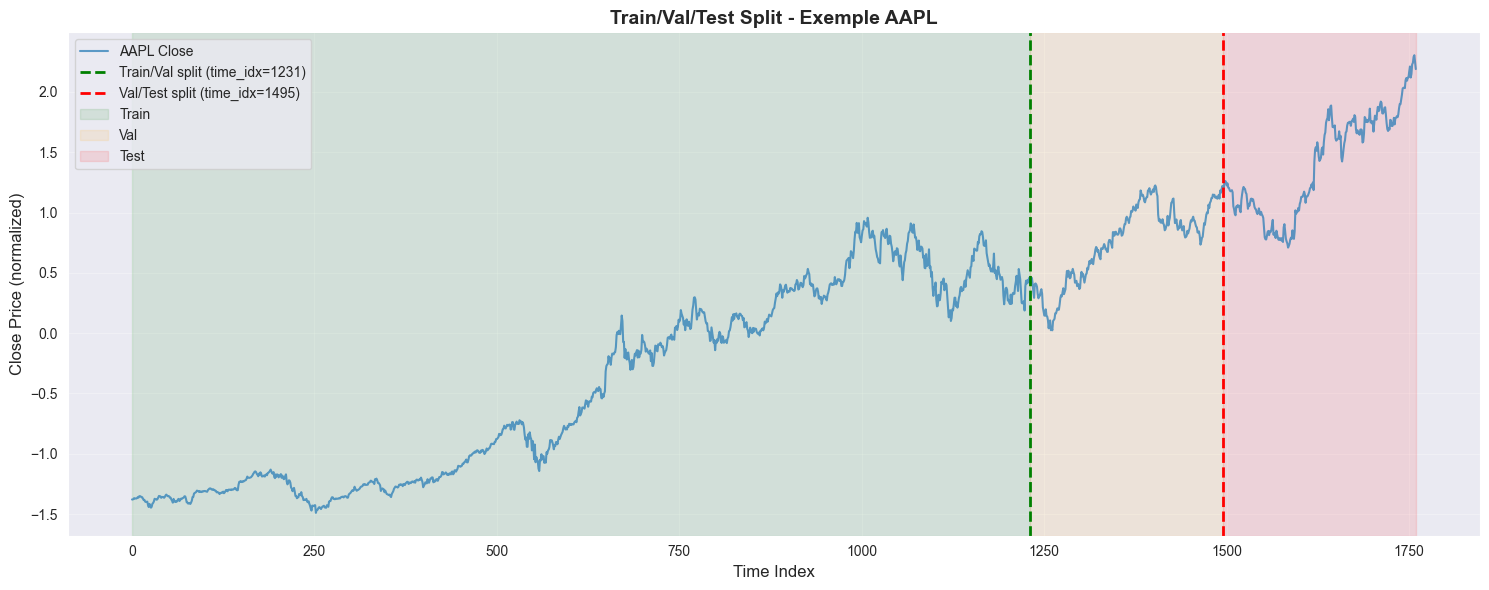

In [11]:
# ============================================
# TRAIN / VALIDATION / TEST SPLIT TEMPOREL
# ============================================

print("\n" + "=" * 70)
print("✂️  TRAIN / VALIDATION / TEST SPLIT")
print("=" * 70)

# Split temporel (important pour séries temporelles)
# 70% train, 15% validation, 15% test

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

# Calculer les cutoffs basés sur time_idx
# (tous les tickers ont le même max time_idx)
max_time_idx = df_normalized['time_idx'].max()
train_cutoff = int(max_time_idx * train_ratio)
val_cutoff = int(max_time_idx * (train_ratio + val_ratio))

print(f"\n📊 Configuration du split:")
print(f"   Max time_idx: {max_time_idx}")
print(f"   Train ratio: {train_ratio:.0%} → time_idx ≤ {train_cutoff}")
print(f"   Val ratio: {val_ratio:.0%} → time_idx ∈ ({train_cutoff}, {val_cutoff}]")
print(f"   Test ratio: {test_ratio:.0%} → time_idx > {val_cutoff}")

# Créer les splits
train_df = df_normalized[df_normalized['time_idx'] <= train_cutoff].copy()
val_df = df_normalized[
    (df_normalized['time_idx'] > train_cutoff) & 
    (df_normalized['time_idx'] <= val_cutoff)
].copy()
test_df = df_normalized[df_normalized['time_idx'] > val_cutoff].copy()

# Statistiques des splits
print(f"\n✅ Splits créés:")
print(f"\n   📁 TRAIN:")
print(f"      Lignes: {len(train_df):,} ({len(train_df)/len(df_normalized)*100:.1f}%)")
print(f"      Période: {train_df['Date'].min().date()} → {train_df['Date'].max().date()}")
print(f"      Time idx: {train_df['time_idx'].min()} → {train_df['time_idx'].max()}")

print(f"\n   📁 VALIDATION:")
print(f"      Lignes: {len(val_df):,} ({len(val_df)/len(df_normalized)*100:.1f}%)")
print(f"      Période: {val_df['Date'].min().date()} → {val_df['Date'].max().date()}")
print(f"      Time idx: {val_df['time_idx'].min()} → {val_df['time_idx'].max()}")

print(f"\n   📁 TEST:")
print(f"      Lignes: {len(test_df):,} ({len(test_df)/len(df_normalized)*100:.1f}%)")
print(f"      Période: {test_df['Date'].min().date()} → {test_df['Date'].max().date()}")
print(f"      Time idx: {test_df['time_idx'].min()} → {test_df['time_idx'].max()}")

# Visualisation du split
print(f"\n📊 Visualisation du split par ticker:")

fig, ax = plt.subplots(figsize=(15, 6))

# Plot un ticker exemple
example_ticker = 'AAPL'
ticker_data = df_normalized[df_normalized['Ticker'] == example_ticker]

ax.plot(ticker_data['time_idx'], ticker_data['Close'], 
        label=f'{example_ticker} Close', linewidth=1.5, alpha=0.7)

# Lignes de séparation
ax.axvline(train_cutoff, color='green', linestyle='--', linewidth=2, 
           label=f'Train/Val split (time_idx={train_cutoff})')
ax.axvline(val_cutoff, color='red', linestyle='--', linewidth=2, 
           label=f'Val/Test split (time_idx={val_cutoff})')

# Zones colorées
ax.axvspan(0, train_cutoff, alpha=0.1, color='green', label='Train')
ax.axvspan(train_cutoff, val_cutoff, alpha=0.1, color='orange', label='Val')
ax.axvspan(val_cutoff, max_time_idx, alpha=0.1, color='red', label='Test')

ax.set_xlabel('Time Index', fontsize=12)
ax.set_ylabel('Close Price (normalized)', fontsize=12)
ax.set_title(f'Train/Val/Test Split - Exemple {example_ticker}', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 70)


In [12]:
# ============================================
# SAUVEGARDE DES DONNÉES ET CONFIGURATION
# ============================================

print("\n" + "=" * 70)
print("💾 SAUVEGARDE DES DONNÉES")
print("=" * 70)

# Créer le dossier TFT
tft_dir = config.data_dir / 'tft'
tft_dir.mkdir(parents=True, exist_ok=True)

# 1. Sauvegarder les datasets
train_path = tft_dir / 'train_data.csv'
val_path = tft_dir / 'val_data.csv'
test_path = tft_dir / 'test_data.csv'
full_path = tft_dir / 'full_data_normalized.csv'

print(f"\n⏳ Sauvegarde des datasets...")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)
df_normalized.to_csv(full_path, index=False)

print(f"\n✅ Datasets sauvegardés:")
print(f"   📄 Train: {train_path}")
print(f"      Taille: {train_path.stat().st_size / 1024**2:.2f} MB")
print(f"   📄 Validation: {val_path}")
print(f"      Taille: {val_path.stat().st_size / 1024**2:.2f} MB")
print(f"   📄 Test: {test_path}")
print(f"      Taille: {test_path.stat().st_size / 1024**2:.2f} MB")
print(f"   📄 Full (normalized): {full_path}")
print(f"      Taille: {full_path.stat().st_size / 1024**2:.2f} MB")

# 2. Sauvegarder les scalers
import pickle

scalers_path = tft_dir / 'scalers.pkl'
with open(scalers_path, 'wb') as f:
    pickle.dump(scalers, f)

print(f"\n   📦 Scalers: {scalers_path}")
print(f"      Nombre: {len(scalers)}")
print(f"      Taille: {scalers_path.stat().st_size / 1024:.2f} KB")

# 3. Sauvegarder la configuration TFT
import json

tft_config = {
    'static_features': static_features,
    'time_varying_known': time_varying_known,
    'time_varying_unknown': time_varying_unknown,
    'target': target,
    'max_encoder_length': 60,  # Historique de 60 jours
    'max_prediction_length': 5,  # Prédire 5 jours
    'train_cutoff': int(train_cutoff),
    'val_cutoff': int(val_cutoff),
    'max_time_idx': int(max_time_idx),
    'num_tickers': int(df['Ticker'].nunique()),
    'tickers': sorted(df['Ticker'].unique().tolist()),
    'date_range': {
        'start': str(df['Date'].min().date()),
        'end': str(df['Date'].max().date())
    },
    'dataset_sizes': {
        'train': len(train_df),
        'val': len(val_df),
        'test': len(test_df),
        'total': len(df_normalized)
    }
}

config_path = tft_dir / 'tft_config.json'
with open(config_path, 'w') as f:
    json.dump(tft_config, f, indent=2)

print(f"\n   ⚙️  Config TFT: {config_path}")
print(f"      Features: {len(time_varying_known) + len(time_varying_unknown)}")

# 4. Sauvegarder metadata
metadata = {
    'creation_date': str(datetime.now()),
    'total_features': len(df_normalized.columns),
    'normalization_method': 'StandardScaler per ticker',
    'split_method': 'temporal',
    'split_ratios': {
        'train': train_ratio,
        'val': val_ratio,
        'test': test_ratio
    }
}

metadata_path = tft_dir / 'metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n   📋 Metadata: {metadata_path}")

print(f"\n✅ Tous les fichiers sauvegardés dans:")
print(f"   {tft_dir}")

print("=" * 70)



💾 SAUVEGARDE DES DONNÉES

⏳ Sauvegarde des datasets...

✅ Datasets sauvegardés:
   📄 Train: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\tft\train_data.csv
      Taille: 31.20 MB
   📄 Validation: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\tft\val_data.csv
      Taille: 6.67 MB
   📄 Test: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\tft\test_data.csv
      Taille: 6.64 MB
   📄 Full (normalized): c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\tft\full_data_normalized.csv
      Taille: 44.51 MB

   📦 Scalers: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\tft\scalers.pkl
      Nombre: 1180
      Taille: 214.92 KB

   ⚙️  Config TFT: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\tft\tft_config.json
      Features: 70

   📋 Metadata: c:\Users\lenovo\OneDrive\Bureau\cours\sentiTrade-HMA-V2\data\tft\metadata.json

✅ Tous les fichiers sauvegardés dans:
   c:\Users\lenovo\OneDrive\Bureau\cours\sentiTra

In [13]:
# ============================================
# RÉSUMÉ FINAL
# ============================================

print("\n" + "=" * 80)
print("=" * 80)
print("✅ FEATURE ENGINEERING POUR TFT TERMINÉ !".center(80))
print("=" * 80)
print("=" * 80)

print(f"\n{'📊 STATISTIQUES FINALES':^80}")
print("-" * 80)

print(f"\n{'DONNÉES':^80}")
print(f"   Dataset original:           {len(df):,} lignes")
print(f"   Dataset TFT:                {len(df_tft):,} lignes")
print(f"   Période:                    {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"   Durée:                      {(df['Date'].max() - df['Date'].min()).days} jours (~{(df['Date'].max() - df['Date'].min()).days/365:.1f} ans)")
print(f"   Tickers:                    {df['Ticker'].nunique()}")
print(f"   Points par ticker:          {len(df) // df['Ticker'].nunique()}")

print(f"\n{'FEATURES':^80}")
print(f"   Total colonnes:             {len(df_tft.columns)}")
print(f"   Static features:            {len(static_features)}")
print(f"   Time-varying known:         {len(time_varying_known)}")
print(f"   Time-varying unknown:       {len(time_varying_unknown)}")
print(f"   Target:                     {target}")

print(f"\n{'SPLITS':^80}")
print(f"   Train:                      {len(train_df):,} lignes ({len(train_df)/len(df_normalized)*100:.1f}%)")
print(f"   Validation:                 {len(val_df):,} lignes ({len(val_df)/len(df_normalized)*100:.1f}%)")
print(f"   Test:                       {len(test_df):,} lignes ({len(test_df)/len(df_normalized)*100:.1f}%)")

print(f"\n{'FICHIERS GÉNÉRÉS':^80}")
print(f"   ✅ train_data.csv")
print(f"   ✅ val_data.csv")
print(f"   ✅ test_data.csv")
print(f"   ✅ full_data_normalized.csv")
print(f"   ✅ scalers.pkl ({len(scalers)} scalers)")
print(f"   ✅ tft_config.json")
print(f"   ✅ metadata.json")

print(f"\n{'PROCHAINE ÉTAPE':^80}")
print(f"   🚀 Notebook 05: TFT Training")
print(f"      → Entraînement du Temporal Fusion Transformer")
print(f"      → Hyperparameter tuning")
print(f"      → Validation et métriques")

print("\n" + "=" * 80)
print("=" * 80)



                    ✅ FEATURE ENGINEERING POUR TFT TERMINÉ !                    

                             📊 STATISTIQUES FINALES                             
--------------------------------------------------------------------------------

                                    DONNÉES                                     
   Dataset original:           35,200 lignes
   Dataset TFT:                35,200 lignes
   Période:                    2018-01-02 → 2024-12-30
   Durée:                      2554 jours (~7.0 ans)
   Tickers:                    20
   Points par ticker:          1760

                                    FEATURES                                    
   Total colonnes:             73
   Static features:            1
   Time-varying known:         11
   Time-varying unknown:       59
   Target:                     Close

                                     SPLITS                                     
   Train:                      24,640 lignes (70.0%)
   Validation:  